# Modelado predictivo

En esta sección se desarrolla un modelo de aprendizaje supervisado con el objetivo de predecir la incidencia territorial de la violencia de género.

Se plantea un problema de clasificación binaria basado en la variable `riesgo_alto`.

In [0]:
df = spark.read.format("delta").load(
    "/Volumes/workspace/default/tfm_visnu_raw/exports/df_analitico_delta"
)

display(df)

anio,provincia,denuncias,victimas,ordenes_proteccion,quebrantamientos,poblacion_hombres,poblacion_mujeres,poblacion_total,renta_media_hogar,renta_media_persona,tasa_actividad_total,tasa_actividad_hombres,tasa_actividad_mujeres,tasa_empleo_total,tasa_empleo_hombres,tasa_empleo_mujeres,tasa_paro_total,tasa_paro_hombres,tasa_paro_mujeres,tasa_denuncias_100k,tasa_victimas_100k,tasa_ordenes_100k,tasa_quebrantamientos_100k,ratio_ordenes_denuncias,ratio_quebrantamientos_denuncias,porcentaje_mujeres,riesgo_alto
2021,A CORUNA,1943.0,1916.0,700.0,241.0,537361.0,583140.0,1120501.0,32643.0,13319.0,52.70249999999999,57.724999999999994,48.167500000000004,47.122499999999995,51.915,42.795,10.6,10.094999999999999,11.145,173.4045752748101,170.99493887109426,62.472054911151346,21.50823604798211,0.3602676273803397,0.1240349974266598,0.5204279157269829,0
2021,A CORUNA,54.0,54.0,24.0,11.0,537361.0,583140.0,1120501.0,32643.0,13319.0,52.70249999999999,57.724999999999994,48.167500000000004,47.122499999999995,51.915,42.795,10.6,10.094999999999999,11.145,4.819272807431675,4.819272807431675,2.1418990255251895,0.9817037200323784,0.4444444444444444,0.2037037037037037,0.5204279157269829,0
2021,ALAVA,53.0,53.0,5.0,1.0,164299.0,169186.0,333485.0,36546.0,15539.0,57.25749999999999,61.7725,52.942499999999995,50.755,54.29,47.37499999999999,11.365,12.129999999999999,10.522499999999999,15.89276879020046,15.89276879020046,1.4993178103962697,0.29986356207925396,0.09433962264150944,0.018867924528301886,0.5073271661394065,0
2021,ALBACETE,969.0,956.0,336.0,108.0,193487.0,193239.0,386726.0,29451.0,11652.0,57.052499999999995,63.6175,50.55499999999999,48.165,56.010000000000005,40.4075,15.5275,11.9675,19.91,250.56499950869608,247.20344636771256,86.88321964388223,27.92674917124786,0.34674922600619196,0.11145510835913312,0.49967935954655235,0
2021,ALICANTE,10659.0,10627.0,2984.0,1433.0,935234.0,951802.0,1887036.0,27380.0,10770.0,56.585,62.307500000000005,51.015,46.00000000000001,52.14,40.0275,18.705,16.325,21.5225,564.854088634239,563.1583075256647,158.1315883745726,75.93919776835206,0.27995121493573505,0.13444037902242237,0.5043899533448223,1
2021,ALMERIA,2433.0,2218.0,580.0,348.0,372823.0,357607.0,730430.0,27184.0,10103.0,61.765,69.485,53.765,49.89,57.025,42.4875,19.255000000000003,17.97,20.9875,333.09146667031746,303.656750133483,79.40528182029763,47.64316909217858,0.23838882038635428,0.14303329223181258,0.4895842175157099,1
2021,ASTURIAS,1578.0,1571.0,421.0,246.0,483186.0,528931.0,1012117.0,31623.0,14057.0,50.412499999999994,55.3125,46.027499999999996,44.19,49.055,39.8375,12.335,11.317499999999999,13.4275,155.91082849117245,155.21920884640807,41.5959814922583,24.305490373148558,0.26679340937896073,0.155893536121673,0.5225986718926764,0
2021,AVILA,374.0,374.0,141.0,42.0,79884.0,79014.0,158898.0,27023.0,12123.0,52.325,57.545,47.06,44.2,51.68749999999999,36.655,15.49,10.1675,22.03,235.37111857921434,235.37111857921434,88.73617037344711,26.432050749537442,0.3770053475935829,0.11229946524064172,0.4972623947437979,0
2021,BADAJOZ,1970.0,1970.0,650.0,130.0,331856.0,339236.0,671092.0,26050.0,10549.0,55.74499999999999,62.4475,49.287499999999994,44.32,52.62499999999999,36.3175,20.5275,15.7625,26.332499999999996,293.55140576850863,293.55140576850863,96.85706281702062,19.37141256340412,0.3299492385786802,0.06598984771573604,0.5054985009506894,0
2021,BARCELONA,11536.0,11262.0,2780.0,1335.0,2785890.0,2916372.0,5702262.0,39511.0,15297.0,61.370000000000005,65.91,57.1325,54.4225,59.2025,49.957499999999996,11.327499999999999,10.1775,12.5625,202.30568149972763,197.50057082610377,48.75258274698707,23.411761858715014,0.24098474341192788,0.1157246879334258,0.5114412491043028,0


In [0]:
pdf = df.toPandas()

## Definición de variables

In [0]:
features = [
    "poblacion_total",
    "poblacion_mujeres",
    "renta_media_persona",
    "renta_media_hogar",
    "tasa_actividad_mujeres",
    "tasa_empleo_mujeres",
    "tasa_paro_mujeres",
    "porcentaje_mujeres"
]

target = "riesgo_alto"

## División del dataset

In [0]:
from sklearn.model_selection import train_test_split

X = pdf[features]
y = pdf[target]

print("Distribución absoluta:")
print(y.value_counts())

print("\nDistribución relativa:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Distribución absoluta:
riesgo_alto
0    117
1     42
Name: count, dtype: int64

Distribución relativa:
riesgo_alto
0    0.735849
1    0.264151
Name: proportion, dtype: float64


## Modelo base: Regresión logística

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        24
           1       0.57      0.50      0.53         8

    accuracy                           0.78        32
   macro avg       0.71      0.69      0.70        32
weighted avg       0.77      0.78      0.78        32



## Modelo Random Forest

In [0]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88        24
           1       0.75      0.38      0.50         8

    accuracy                           0.81        32
   macro avg       0.79      0.67      0.69        32
weighted avg       0.80      0.81      0.79        32



## Importancia de variables

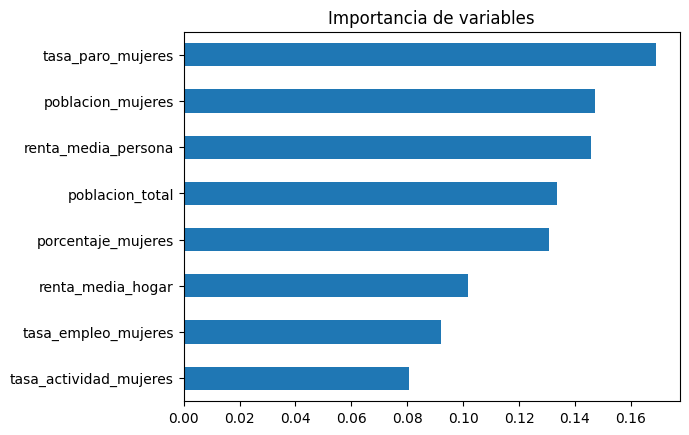

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=features)

plt.figure()
importances.sort_values().plot(kind="barh")

plt.title("Importancia de variables")
plt.show()

## Evaluación del modelo

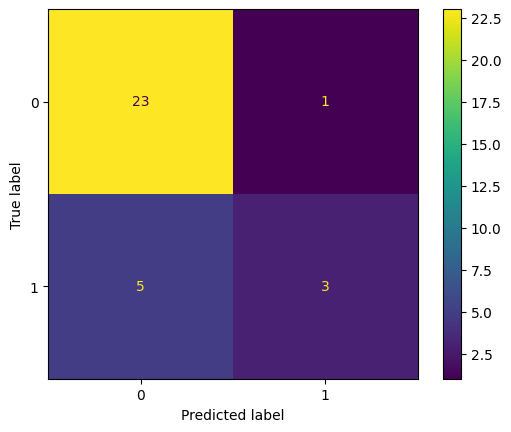

In [0]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

## Conclusiones del modelado

Los modelos entrenados permiten realizar una primera aproximación predictiva al problema de clasificación de provincias con alto riesgo relativo de incidencia de violencia de género.

El modelo Random Forest obtiene un rendimiento ligeramente superior al modelo base de regresión logística, alcanzando una accuracy del 75%. No obstante, el análisis de precision, recall y f1-score muestra que la detección de la clase minoritaria (`riesgo_alto = 1`) presenta todavía margen de mejora.

Este resultado es coherente con las limitaciones del dataset, especialmente el número reducido de observaciones disponibles y el posible desbalance entre clases.

Por tanto, el modelo no debe interpretarse como una herramienta predictiva definitiva, sino como una primera aproximación analítica que permite evaluar la capacidad explicativa de variables socioeconómicas y demográficas.

Se han excluido variables directamente relacionadas con la variable objetivo (como denuncias o tasas derivadas) para evitar problemas de data leakage.